In [1]:
import warnings
from json import dumps
from pickle import Pickler
from shutil import rmtree
from pathlib import Path
from typing import Literal
from gzip import open as gz_open
from joblib import Memory

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, minmax_scale
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score


RANDOM_STATE = 12345
VIF_THRESHOLD = 10.0

# Dados

In [2]:
def get_vif_removal_features(threshold: float) -> frozenset[str]:
    vif_values = Path("../datasense/dataset/vif_values.csv")
    vif_values = pd.read_csv(vif_values)
    vif_values = vif_values[vif_values["vif"] >= threshold]
    return frozenset(vif_values["feature"])


def get_transformer(data: pd.DataFrame, vif_threshold: float = VIF_THRESHOLD):
    log1p_transformer = FunctionTransformer(np.log1p, feature_names_out="one-to-one")
    number_selector = make_column_selector(dtype_include="number")
    bool_selector = make_column_selector(dtype_include="bool")
    first_transformer = make_column_transformer(
        (make_pipeline(log1p_transformer, MinMaxScaler()), number_selector),
        (OneHotEncoder(sparse_output=False), ["device_type"]),
        ("passthrough", bool_selector),
        remainder="drop",
        verbose_feature_names_out=False,
    )
    _ = first_transformer.fit_transform(data)
    feature_names = first_transformer.get_feature_names_out()
    vif_removal = get_vif_removal_features(vif_threshold)
    vif_indexes = [i for i, ft in enumerate(feature_names) if ft in vif_removal]
    second_transformer = make_column_transformer(
        ("drop", vif_indexes),
        remainder="passthrough",
        verbose_feature_names_out=False,
    )
    return make_pipeline(first_transformer, second_transformer)


def prepare_experiment(
    target: Literal["binary", "condensed", "granular"],
    overwrite: bool = False,
):
    experiment = {}
    dataset_path = Path("../datasense/dataset/")
    for split in ["train", "test"]:
        split_data = dataset_path / f"datasense_1sec_{split}.parquet"
        split_data = pd.read_parquet(split_data)
        if target == "binary":
            y_split = split_data["label1"]
        elif target == "condensed":
            y_split = split_data["label2"]
        elif target == "granular":
            y_split = split_data["label4"]
        else:
            raise ValueError("Unknown target")
        experiment[split] = (split_data, y_split)
    X_train, y_train = experiment["train"]
    experiment["classes"] = sorted(y_train.unique())
    experiment["transformer"] = get_transformer(X_train)
    results_dir = Path(f"results/logistic_regression__{target}")
    if results_dir.is_dir():
        if overwrite:
            rmtree(results_dir, ignore_errors=True)
        else:
            raise RuntimeError(
                "Experiment already executed and overwrite set to False"
            )
    results_dir.mkdir(exist_ok=True, parents=True)
    cache_dir = results_dir / ".cache"
    cache_dir.mkdir()
    experiment["results_dir"] = results_dir
    experiment["cache_dir"] = Memory(location=cache_dir, verbose=0)
    return experiment

In [3]:
experiment = prepare_experiment(target="granular", overwrite=True)

X_train, y_train = experiment["train"]
class_names = experiment["classes"]
num_classes = len(class_names)
X_test, y_test = experiment["test"]
results_dir = experiment["results_dir"]
cache_dir = experiment["cache_dir"]

# Experiment

## Training pipe

In [4]:
model = LogisticRegression(
    max_iter=6000,
    l1_ratio=0.0,
    solver="lbfgs",
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

In [5]:
train_pipe = Pipeline(
    steps=[
        ("transformer", experiment["transformer"]),
        ("model", model),
    ],
    memory=cache_dir,
    verbose=False,
)

## Grid seach cross-validation

In [6]:
C_range = [10**i for i in range(-5, 5)]
C_range.append(np.inf)

param_grid = {"model__C": C_range}

In [7]:
grid = GridSearchCV(
    estimator=train_pipe,
    param_grid=param_grid,
    scoring=(
        "f1_macro" if num_classes > 2
        else make_scorer(f1_score, pos_label="attack")
    ),
    n_jobs=4,
    refit=True,
    cv=4,
    verbose=3,
)

with warnings.catch_warnings():
    warnings.filterwarnings(action="ignore", message=r"^Setting penalty=None will ignore")
    warnings.filterwarnings(action="ignore", message=r"^Persisting input arguments took")
    grid.fit(X_train, y_train)

trained_pipe = grid.best_estimator_
trained_model = trained_pipe["model"]

Fitting 4 folds for each of 11 candidates, totalling 44 fits
[CV 4/4] END ....................model__C=1e-05;, score=0.253 total time=   9.0s
[CV 3/4] END ....................model__C=1e-05;, score=0.245 total time=   9.1s
[CV 2/4] END ....................model__C=1e-05;, score=0.260 total time=   9.3s
[CV 1/4] END ....................model__C=1e-05;, score=0.250 total time=   9.2s
[CV 1/4] END ...................model__C=0.0001;, score=0.257 total time=   5.4s
[CV 2/4] END ...................model__C=0.0001;, score=0.269 total time=   5.4s
[CV 4/4] END ...................model__C=0.0001;, score=0.270 total time=   5.4s
[CV 3/4] END ...................model__C=0.0001;, score=0.248 total time=   5.4s
[CV 1/4] END ....................model__C=0.001;, score=0.326 total time=  12.0s
[CV 3/4] END ....................model__C=0.001;, score=0.324 total time=  12.0s
[CV 2/4] END ....................model__C=0.001;, score=0.327 total time=  12.1s
[CV 4/4] END ....................model__C=0.001;

## Cross-validation results

In [8]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results.sort_values(by="rank_test_score", inplace=True)
cv_results.to_csv(results_dir / "train_cv_results.csv", index=False)
cv_results.head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
7,260.274928,25.486011,0.525275,0.253889,100.0000,{'model__C': 100},0.572111,0.567560,0.573568,0.563268,0.569127,0.004044,1
6,185.502314,12.191728,0.701351,0.017965,10.0000,{'model__C': 10},0.576534,0.563807,0.569645,0.563386,0.568343,0.005337,2
5,99.039731,2.472708,0.581146,0.300179,1.0000,{'model__C': 1},0.569845,0.561615,0.560589,0.570115,0.565541,0.004455,3
9,266.396306,34.625913,0.714716,0.025365,10000.0000,{'model__C': 10000},0.572590,0.559534,0.574584,0.554077,0.565196,0.008638,4
10,315.775368,36.529749,0.470739,0.155186,inf,{'model__C': inf},0.572341,0.556018,0.573343,0.557317,0.564755,0.008108,5
8,332.094282,20.350733,0.721245,0.046925,1000.0000,{'model__C': 1000},0.571015,0.554638,0.572786,0.553340,0.562945,0.008989,6
4,47.150313,0.983638,0.686872,0.031177,0.1000,{'model__C': 0.1},0.536184,0.528180,0.525175,0.531826,0.530341,0.004114,7
3,22.579536,1.683996,0.637417,0.084028,0.0100,{'model__C': 0.01},0.455128,0.453355,0.442562,0.452867,0.450978,0.004931,8
2,11.618766,0.247235,0.535075,0.060689,0.0010,{'model__C': 0.001},0.326428,0.327477,0.323572,0.330792,0.327067,0.002582,9
1,4.935659,0.057461,0.475564,0.053949,0.0001,{'model__C': 0.0001},0.256823,0.268918,0.247855,0.270218,0.260953,0.009191,10


## Feature importance

In [9]:
feature_names = trained_pipe["transformer"].get_feature_names_out()
importances = np.abs(trained_model.coef_).mean(axis=0)
feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
})
feature_importances.sort_values(
    by="importance", ascending=False,
    ignore_index=True, inplace=True,
)
feature_importances["importance_norm"] = minmax_scale(feature_importances["importance"])
feature_importances.to_csv(results_dir / "feature_importances.csv", index=False)

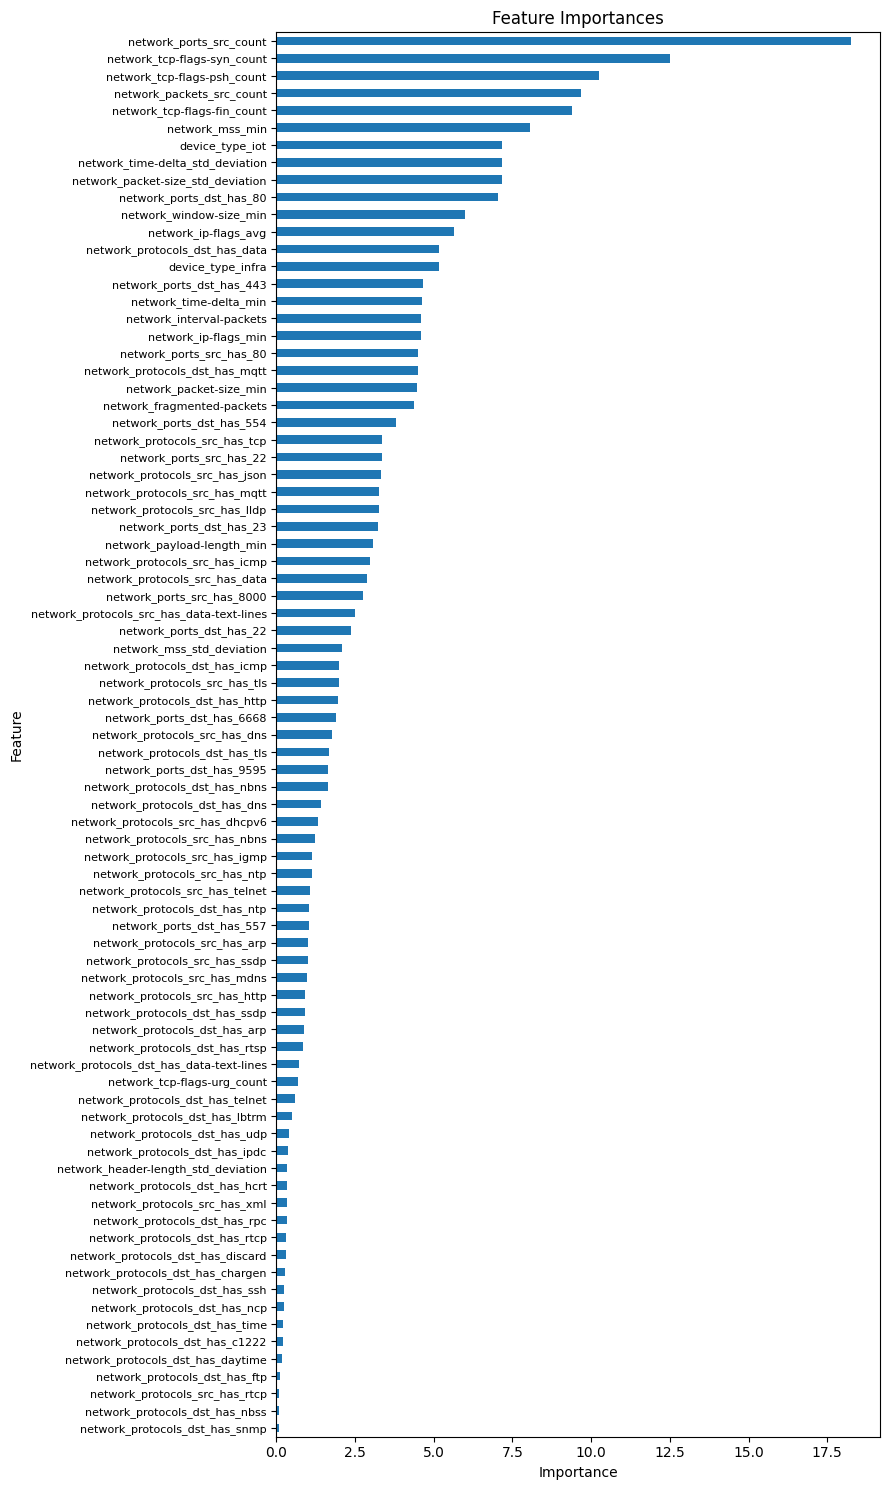

In [10]:
fig, ax = plt.subplots(figsize=(9, 15))

feature_importances["importance"].plot(kind="barh", ax=ax)

ax.invert_yaxis()
ax.set_yticks(
    ticks=range(feature_importances.shape[0]),
    labels=feature_importances["feature"],
    fontsize=8,
)
ax.set_title("Feature Importances")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.savefig(results_dir / "feature_importances.png", dpi=300)
plt.show()

# Model evaluations

## Train-split evaluations

In [11]:
y_proba = trained_pipe.predict_proba(X_train)

train_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

train_results.to_parquet(
    results_dir / "train_predict_proba.parquet",
    index=False,
    compression="gzip",
)

## Test-split evaluations

In [12]:
y_proba = trained_pipe.predict_proba(X_test)

test_results = pd.DataFrame(
    data=y_proba,
    columns=trained_pipe.classes_,
    dtype="float32",
)

test_results.to_parquet(
    results_dir / "test_predict_proba.parquet",
    index=False,
    compression="gzip",
)

# Model summary and persistency

## Model persistency

In [13]:
pipe_persist_path = results_dir / "pipe.pickle.gz"

with gz_open(pipe_persist_path, mode="wb") as pf:
    Pickler(pf, protocol=5).dump(trained_pipe)

## Model summary

In [14]:
model_summary = {
    "best_parameters": grid.best_params_,
    "all_parameters": trained_model.get_params(),
}

model_summary = dumps(model_summary, indent=2)
(results_dir / "model_summary.json").write_text(model_summary)
print("MODEL SUMMARY:", model_summary, sep="\n")

MODEL SUMMARY:
{
  "best_parameters": {
    "model__C": 100
  },
  "all_parameters": {
    "C": 100,
    "class_weight": "balanced",
    "dual": false,
    "fit_intercept": true,
    "intercept_scaling": 1,
    "l1_ratio": 0.0,
    "max_iter": 6000,
    "n_jobs": null,
    "penalty": "deprecated",
    "random_state": 12345,
    "solver": "lbfgs",
    "tol": 0.0001,
    "verbose": 0,
    "warm_start": false
  }
}
